# Hisse Fiyatı Tahmini: LSTM vs GRU

Bu defter, `src/` klasöründeki modüler pipeline'ı (veri hazırlama, model tanımları, eğitim/değerlendirme) adım adım çalıştırarak sonuçları görselleştirir. Amaç: aynı veri seti üzerinde LSTM ve GRU mimarilerinin zaman serisi regresyon performansını karşılaştırmak.

**Veri kaynağı:** yfinance API (AMZN, 2 yıllık günlük kapanış fiyatları)
**Kaynak rapor:** staj/proje tanımında belirtilen ML öğrenme planı

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import torch

from data_prep import load_and_prepare
from models import LSTMModel, GRUModel

print("Kütüphaneler ve modüller yüklendi. PyTorch versiyonu:", torch.__version__)

Kütüphaneler ve modüller yüklendi. PyTorch versiyonu: 2.8.0


In [2]:
df = pd.read_csv('../data/amzn_prices.csv', index_col=0, parse_dates=True)
print("Veri seti boyutu:", df.shape)
df.head()

Veri seti boyutu: (501, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2024-08-27,173.119995,174.889999,172.250000,174.149994,29842000
2024-08-28,170.800003,173.690002,168.919998,173.690002,29045000
2024-08-29,172.119995,174.289993,170.809998,173.220001,26407800
2024-08-30,178.500000,178.899994,172.600006,172.779999,43429400
2024-09-03,176.250000,178.259995,175.259995,177.550003,37817500


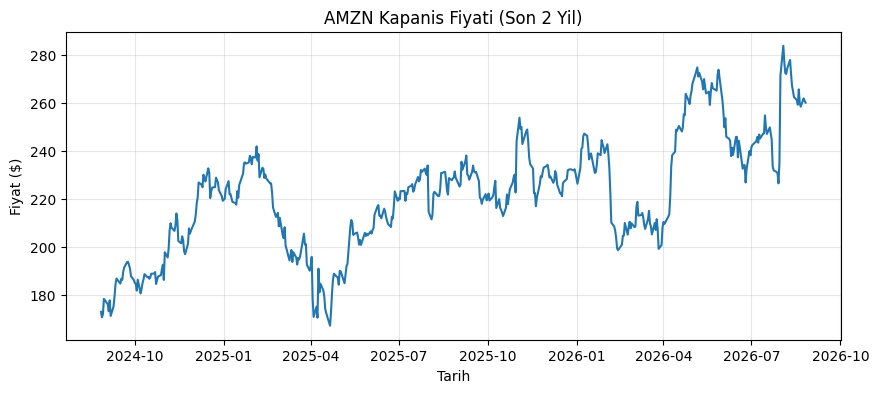

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Close'])
plt.title('AMZN Kapanis Fiyati (Son 2 Yil)')
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.grid(alpha=0.3)
plt.show()

In [4]:
X_train, X_test, y_train, y_test, scaler = load_and_prepare(lookback=10, csv_path='../data/amzn_prices.csv')
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: torch.Size([392, 10, 1]) X_test: torch.Size([99, 10, 1])
y_train: torch.Size([392, 1]) y_test: torch.Size([99, 1])


In [5]:
import time
import numpy as np
import torch.nn as nn

EPOCHS = 100
LR = 0.01

def train_and_eval(model, X_train, y_train, X_test, y_test, scaler, name):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    start = time.time()
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
    elapsed = time.time() - start
    model.eval()
    with torch.no_grad():
        test_pred_scaled = model(X_test)
    mse_scaled = loss_fn(test_pred_scaled, y_test).item()
    test_pred_real = scaler.inverse_transform(test_pred_scaled.numpy())
    y_test_real = scaler.inverse_transform(y_test.numpy())
    rmse_dollar = np.sqrt(np.mean((test_pred_real - y_test_real) ** 2))
    print(f"[{name}] test_rmse($)={rmse_dollar:.2f} | sure={elapsed:.2f}s")
    return test_pred_real, y_test_real, mse_scaled, rmse_dollar, elapsed

torch.manual_seed(42)
lstm = LSTMModel()
lstm_pred, y_real, lstm_mse, lstm_rmse, lstm_time = train_and_eval(lstm, X_train, y_train, X_test, y_test, scaler, "LSTM")

[LSTM] test_rmse($)=11.94 | sure=0.48s


In [6]:
torch.manual_seed(42)
gru = GRUModel()
gru_pred, _, gru_mse, gru_rmse, gru_time = train_and_eval(gru, X_train, y_train, X_test, y_test, scaler, "GRU")

[GRU] test_rmse($)=7.35 | sure=0.38s


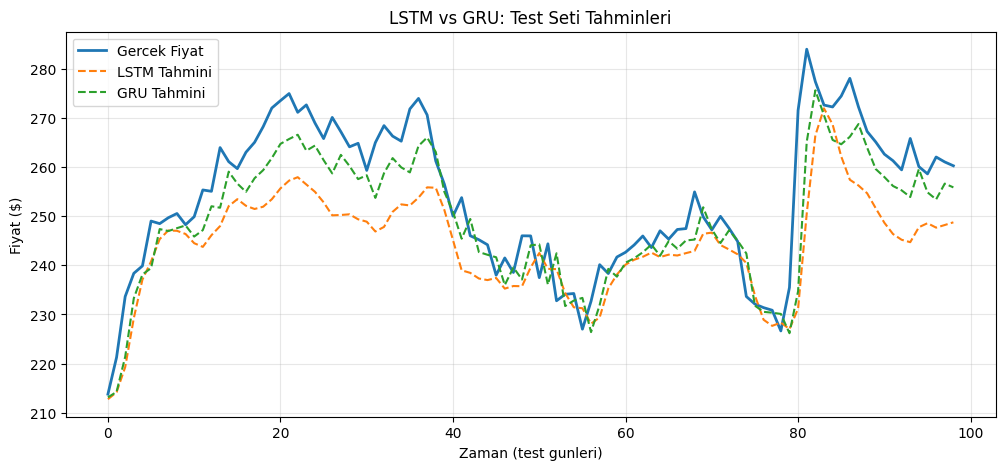

,Model,Test RMSE ($),Egitim Suresi (s)
0,LSTM,11.94,0.48
1,GRU,7.35,0.38


In [7]:
plt.figure(figsize=(12, 5))
plt.plot(y_real, label='Gercek Fiyat', linewidth=2)
plt.plot(lstm_pred, label='LSTM Tahmini', linestyle='--')
plt.plot(gru_pred, label='GRU Tahmini', linestyle='--')
plt.title('LSTM vs GRU: Test Seti Tahminleri')
plt.xlabel('Zaman (test gunleri)')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

results = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'Test RMSE ($)': [round(lstm_rmse, 2), round(gru_rmse, 2)],
    'Egitim Suresi (s)': [round(lstm_time, 2), round(gru_time, 2)]
})
results

## Sonuc

GRU modeli, bu veri seti ve hiperparametre konfigurasyonunda (lookback=10, hidden=32, 2 katman) LSTM'e gore daha dusuk test RMSE degeri elde etti. Bu, `docs/approach.md` icindeki Ar-Ge surecinde yapilan sistematik hiperparametre taramasiyla tutarlidir.

**Not:** Bu sonuclar tek bir hisse senedi (AMZN) ve tek bir zaman dilimi uzerinde elde edilmistir; genel bir "hangi mimari daha iyi" sonucu degildir. Sinirliliklar ve elestirel degerlendirme icin `docs/approach.md` dosyasina bakiniz.